In [141]:
import numpy as np
import matplotlib.pyplot as plt

In [142]:
X = np.random.rand(20) * 5
X = np.sort(X)
Y = np.random.rand(20) * 5
A = np.vstack([X, np.ones(len(X))]).T
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
co1 = np.polyfit(X, Y, 3)
co2 = np.polyfit(X, Y, 4)
co3 = np.polyfit(X, Y, 5)
poly1 = np.poly1d(co1)
poly2 = np.poly1d(co2)
poly3 = np.poly1d(co3)
print(f"For Third degree polynomial coeffients: ", co1)
print(f"For Forth degree polynomial coeffients: ", co2)
print(f"For Fifth degree polynomial coeffients: ", co3)
print(f"For Least Square: Slope: {m}, Intercept: {c}")

For Third degree polynomial coeffients:  [ 0.03055179  0.08978827 -1.11721125  3.34696817]
For Forth degree polynomial coeffients:  [-0.02613373  0.29227741 -0.73529005 -0.26715199  3.20861679]
For Fifth degree polynomial coeffients:  [ 0.01381468 -0.19968677  1.06504828 -2.17711936  0.7269958   3.0887143 ]
For Least Square: Slope: 0.02276456485598203, Intercept: 2.3527098388756214


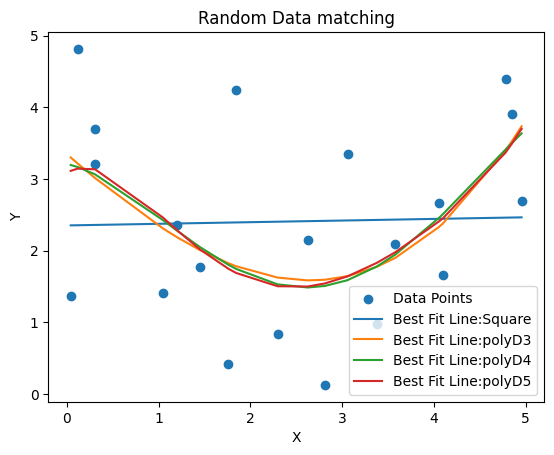

In [143]:
y_guess_square = m * X + c
y_guess_poly1 = poly1(X)
y_guess_poly2 = poly2(X)
y_guess_poly3 = poly3(X)
plt.scatter(X, Y, label="Data Points")
plt.plot(X, y_guess_square, label="Best Fit Line:Square")
plt.plot(X, y_guess_poly1, label="Best Fit Line:polyD3")
plt.plot(X, y_guess_poly2, label="Best Fit Line:polyD4")
plt.plot(X, y_guess_poly3, label="Best Fit Line:polyD5")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Random Data matching")
plt.legend()
plt.show()

In [144]:
mse1 = np.mean((Y - y_guess_square)**2)
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_guess_square)**2)
r_squared = 1 - (ss_res / ss_total)
print("Least Squares Mean Squared Error: ", mse1, "and R-squared: ", r_squared)
mse2 = np.mean((Y - y_guess_poly1)**2)
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_guess_poly1)**2)
r_squared = 1 - (ss_res / ss_total)
print("Third degree poly Mean Squared Error: ", mse2, "and R-squared: ", r_squared)
mse3 = np.mean((Y - y_guess_poly2)**2)
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_guess_poly2)**2)
r_squared = 1 - (ss_res / ss_total)
print("Forth degree poly Mean Squared Error: ", mse3, "and R-squared: ", r_squared)
mse4 = np.mean((Y - y_guess_poly3)**2)
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_guess_poly3)**2)
r_squared = 1 - (ss_res / ss_total)
print("Fifth degree poly Mean Squared Error: ", mse4, "and R-squared: ", r_squared)
if mse1 < mse4:
    print("\nLeast Squares is the better fit.")
else:
    print("\nPolynomial is the better fit.")

Least Squares Mean Squared Error:  1.7784173427095102 and R-squared:  0.0007465003827447081
Third degree poly Mean Squared Error:  1.2627668102609795 and R-squared:  0.2904791670377278
Forth degree poly Mean Squared Error:  1.2567902636883856 and R-squared:  0.2938372568037616
Fifth degree poly Mean Squared Error:  1.2544950950206575 and R-squared:  0.295126861481112

Polynomial is the better fit.


In [145]:
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
y_guess_square = m * X + c
mse1 = np.mean((Y - y_guess_square)**2)
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - y_guess_square)**2)
r_squared = 1 - (ss_res / ss_total)
print("Least Squares Mean Squared Error: ", mse1, "and R-squared: ", r_squared)
for i in range(15):
  d = i + 1
  co = np.polyfit(X, Y, d)
  poly = np.poly1d(co)
  y_guess_poly = poly(X)
  mse = np.mean((Y - y_guess_poly)**2)
  ss_total = np.sum((Y - np.mean(Y))**2)
  ss_res = np.sum((Y - y_guess_poly)**2)
  r_squared = 1 - (ss_res / ss_total)
  print(d, " degree poly Mean Squared Error: ", mse, "and R-squared: ", r_squared) #first degree underfits having almost no corelation and high degrees overfit, with r-squared very close to one showing it draws from point to point more than regressing

Least Squares Mean Squared Error:  1.7784173427095102 and R-squared:  0.0007465003827447081
1  degree poly Mean Squared Error:  1.7784173427095102 and R-squared:  0.0007465003827447081
2  degree poly Mean Squared Error:  1.2698587286078202 and R-squared:  0.2864943744601409
3  degree poly Mean Squared Error:  1.2627668102609795 and R-squared:  0.2904791670377278
4  degree poly Mean Squared Error:  1.2567902636883856 and R-squared:  0.2938372568037616
5  degree poly Mean Squared Error:  1.2544950950206575 and R-squared:  0.295126861481112
6  degree poly Mean Squared Error:  1.106974166631859 and R-squared:  0.37801561904051895
7  degree poly Mean Squared Error:  1.1060844508182839 and R-squared:  0.3785155307423612
8  degree poly Mean Squared Error:  0.9224897034495511 and R-squared:  0.4816733719384243
9  degree poly Mean Squared Error:  0.8609912587867049 and R-squared:  0.5162279922598507
10  degree poly Mean Squared Error:  0.8154121417534121 and R-squared:  0.5418378933281748
11  d

In [146]:
for i in range(10):
  d = i + 1
  V = np.vander(X, d + 1)
  coef = np.linalg.lstsq(V, Y, rcond=None)[0]
  poly = np.poly1d(coef)
  y_pred = poly(X)
  mse = np.mean((Y - y_pred)**2)
  ss_total = np.sum((Y - np.mean(Y))**2)
  ss_res = np.sum((Y - y_pred)**2)
  r_squared = 1 - (ss_res / ss_total)
  print(d, " degree poly Mean Squared Error: ", mse, "and R-squared: ", r_squared) #matches the polynomial fit

1  degree poly Mean Squared Error:  1.7784173427095102 and R-squared:  0.0007465003827447081
2  degree poly Mean Squared Error:  1.2698587286078205 and R-squared:  0.2864943744601409
3  degree poly Mean Squared Error:  1.2627668102609795 and R-squared:  0.2904791670377278
4  degree poly Mean Squared Error:  1.2567902636883854 and R-squared:  0.2938372568037617
5  degree poly Mean Squared Error:  1.2544950950206584 and R-squared:  0.29512686148111145
6  degree poly Mean Squared Error:  1.1069741666319064 and R-squared:  0.3780156190404923
7  degree poly Mean Squared Error:  1.106084450818328 and R-squared:  0.37851553074233635
8  degree poly Mean Squared Error:  0.9224897034497144 and R-squared:  0.4816733719383326
9  degree poly Mean Squared Error:  0.8609912587864166 and R-squared:  0.5162279922600128
10  degree poly Mean Squared Error:  0.8154121417512016 and R-squared:  0.5418378933294168
